In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')

from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function
from connectivity.merge_tree import MergeTree, neighbours_from_adjacency

import matplotlib.pyplot as plt
import pandas as pd
from numpy import unique

In [2]:
# critical_points_file = "./critical_points_schwefel.csv"
critical_points_file = "./critical_points_schwefel_3D.csv"
connectivity_file = "./connectivity_graph_3D.csv"
outdir = './'


dataframe = pd.read_csv(critical_points_file, index_col=0)
no_maxima = dataframe["type"]!="maximum"
dataframe = dataframe[no_maxima]

saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
# minima_df = dataframe[dataframe["type"] != "maximum"]

connectivity_df=pd.read_csv(connectivity_file)

# print(dataframe)
# print(connectivity_df)

In [3]:
connected_nodes = unique(connectivity_df.to_numpy())
connected_mask = dataframe.index.isin(connected_nodes)
dataframe = dataframe[connected_mask]

sorted_cps = dataframe.sort_values('f_value', ascending=False).reset_index() # sort in descending order

from connectivity.saddle_tree_utils import map_coords_to_indices
all_nodes, _, all_types, _ = map_coords_to_indices(sorted_cps)

unsorted_sorted=sorted_cps['index'].reset_index().set_index('index')['level_0'].to_dict()
print(unsorted_sorted)
sorted_unsorted=sorted_cps['index'].to_dict()
print(sorted_unsorted)
input_sorted_vertices = sorted_cps.index.to_list()
# print(input_sorted_vertices)

# print(input_edge_list)
input_edge_list = connectivity_df.to_numpy().tolist()
# print(input_edge_list)
input_edge_list = [[unsorted_sorted[edge[0]], unsorted_sorted[edge[1]]] for edge in input_edge_list]
# print(input_edge_list)
input_critical_points_map = sorted_cps['type']

input_neighbor_map = neighbours_from_adjacency(input_edge_list, input_sorted_vertices)
# drop disconnected nodes 
print(input_neighbor_map)

{100: 0, 48: 1, 45: 2, 71: 3, 62: 4, 28: 5, 115: 6, 73: 7, 99: 8, 63: 9, 101: 10, 68: 11, 69: 12, 79: 13, 38: 14, 78: 15, 93: 16, 32: 17, 74: 18, 40: 19, 33: 20, 47: 21, 111: 22, 113: 23, 55: 24, 91: 25, 106: 26, 65: 27, 85: 28, 59: 29, 102: 30, 105: 31, 96: 32, 97: 33, 1: 34, 107: 35, 81: 36, 42: 37, 83: 38, 36: 39, 72: 40, 86: 41, 31: 42, 84: 43, 5: 44, 15: 45, 26: 46, 52: 47, 114: 48, 108: 49, 75: 50, 30: 51, 41: 52, 8: 53, 21: 54, 16: 55, 56: 56, 70: 57, 43: 58, 54: 59, 58: 60, 60: 61, 39: 62, 46: 63, 76: 64, 6: 65, 2: 66, 22: 67, 3: 68, 14: 69, 18: 70, 23: 71, 17: 72, 20: 73, 24: 74, 44: 75, 109: 76, 67: 77, 9: 78, 11: 79, 13: 80, 4: 81, 10: 82, 25: 83, 0: 84, 12: 85, 7: 86, 19: 87}
{0: 100, 1: 48, 2: 45, 3: 71, 4: 62, 5: 28, 6: 115, 7: 73, 8: 99, 9: 63, 10: 101, 11: 68, 12: 69, 13: 79, 14: 38, 15: 78, 16: 93, 17: 32, 18: 74, 19: 40, 20: 33, 21: 47, 22: 111, 23: 113, 24: 55, 25: 91, 26: 106, 27: 65, 28: 85, 29: 59, 30: 102, 31: 105, 32: 96, 33: 97, 34: 1, 35: 107, 36: 81, 37: 42, 

In [5]:
from connectivity.saddle_tree_utils import dfs_order, bfs_order, save_tree_nodes_csv, prune_graph

tree_processor = MergeTree(
    sorted_vertices=input_sorted_vertices,
    neighbor_map=input_neighbor_map,
    critical_points_map=input_critical_points_map
)

tree_processor.compute_join_tree()

# print(list(tree_processor.prev.items()))
tree_adjacency_list = [[k, v] for k, v in tree_processor.prev.items()]

all_values = sorted_cps['f_value']
root_id = sorted_cps.index[0]

# tree_adjacency = pd.DataFrame({'index_1': tree_processor.prev.keys(), 'index_2': tree_processor.prev.values()})

# simplify tree by node removal:
_, tree_adjacency_list, _ = prune_graph(all_values, input_sorted_vertices, tree_adjacency_list, all_types, root_id)

# compute DFS layout for visualisation
dfs_order_list = dfs_order(tree_adjacency_list, len(all_values), root_id, all_values, input_sorted_vertices)
# dfs_order_list = bfs_order(tree_adjacency_list, len(all_values), root_id, all_values, input_sorted_vertices)
print(input_sorted_vertices)
print(dfs_order_list)

# write out adjacency
#
# get back to original unsorted node names:
tree_adjacency_list = [[sorted_unsorted[n1], sorted_unsorted[n2]] for (n1, n2) in tree_adjacency_list]
tree_adjacency = pd.DataFrame(tree_adjacency_list, columns=['index_1', 'index_2'])
# tree_adjacency = pd.DataFrame({'index_1': tree_adjacency_list[:,0], 'index_2': tree_adjacency_list[:,1]})
tree_adjacency.to_csv('tree_adjacency.csv')


# write out nodes
#
# get back to original unsorted node names:
# dfs_order_list = [sorted_unsorted[n] for n in dfs_order_list]
save_tree_nodes_csv(sorted_unsorted, all_values, dfs_order_list, out_dir=outdir)

# tree_nodes = pd.DataFrame({'index': input_sorted_vertices, 'f_value': all_values, 'order': dfs_order_list})
# tree_nodes = sorted_cps[['f_value']].reset_index().reset_index()
# tree_nodes.rename(columns={'f_value': 'f_value', 'level_0': 'order'}, inplace=True)
# # tree_nodes = tree_nodes[]
# print(tree_nodes)
# tree_nodes.to_csv('tree_nodes.csv', index=None)

Computing Join Tree...
Setting new_root index = 0
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]
[0, np.int64(18), np.int64(34), np.int64(21), np.int64(43), np.int64(64), np.int64(87), np.int64(75), np.int64(85), np.int64(82), np.int64(76), np.int64(84), np.int64(81), np.int64(77), np.int64(86), np.int64(83), np.int64(49), np.int64(66), np.int64(60), np.int64(80), np.int64(69), np.int64(70), np.int64(51), np.int64(65), np.int64(57), np.int64(79), np.int64(73), np.int64(71), np.int64(52), np.int64(67), np.int64(61), np.int64(78), np.int64(72), np.int64(74), np.int64(27), np.int64(44), np.int64(45), np.int64(46), np.int64(37), np.int64(68), np.int64(53), np.int64(54), np.int64(55)]
Saved node orde

/tmp/ipykernel_1179246/2694746100.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


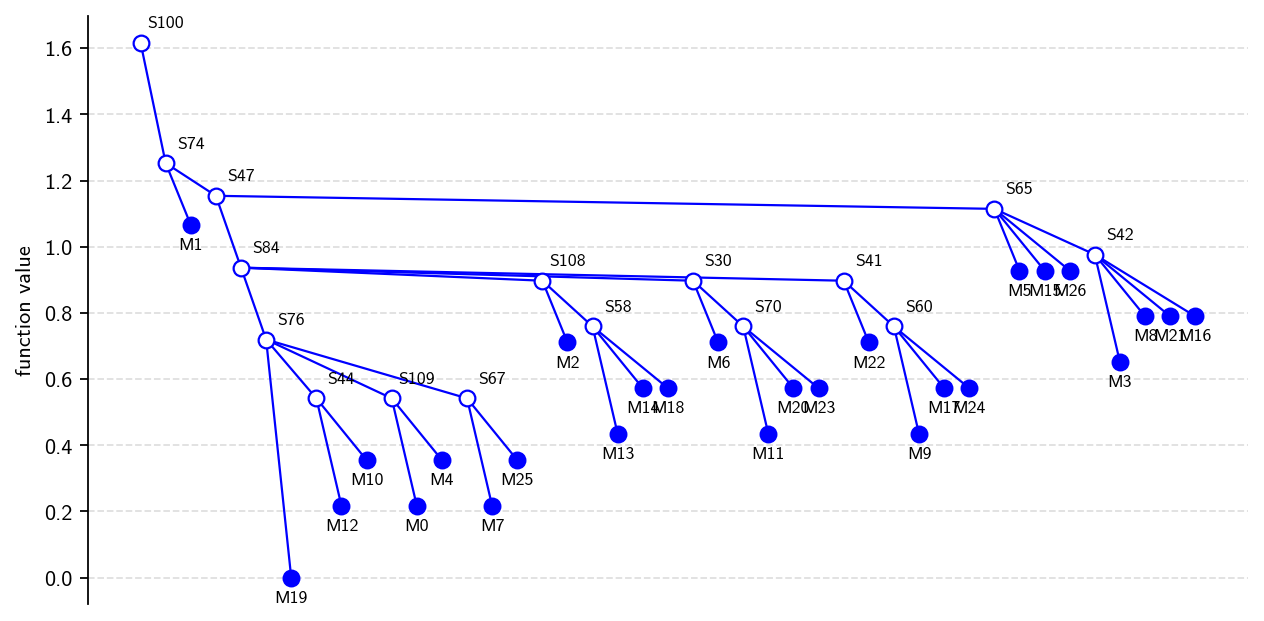

In [6]:
fig1 = plt.figure(figsize=(8,4), dpi=160)
fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv=outdir+"/tree_nodes.csv",
                                      edges_csv=outdir+"/tree_adjacency.csv", 
                                      fig=fig1,
                                      txt_pads=(2, 6e-2))

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
# fig1.savefig(outdir+"/tree_plot.png")  # Optional